In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import optim
from torch.utils.data import DataLoader
from torch.utils.data.dataset import Dataset

In [3]:
%run MLdata.ipynb

# Multilayer Perceptrion (MLP)

In [13]:
class MLPhlayer(nn.Module):
    def __init__(self, in_size, out_size, norm=None):
        super(MLPhlayer, self).__init__()
        self.norm = norm
        self.fc = nn.Linear(in_size, out_size)
        self.act = nn.ReLU()
        if norm:
            self.norm = nn.LayerNorm(out_size)
    
    def forward(self, x):
        x = self.act(self.fc(x))
        if self.norm:
            x = self.norm(x)
        return x

class MLP(nn.Module):
    def __init__(self, in_size, h_size, out_size, norm=None):
        super(MLP, self).__init__()
        self.norm = norm
        self.fcIN = nn.Linear(in_size, h_size[0])
        self.fcOUT = nn.Linear(h_size[-1], out_size)
        self.act = nn.ReLU()
        if norm:
            self.norm = nn.LayerNorm(h_size[0])
        #self.dropout1 = nn.Dropout(0.25)
        self.hlayers = nn.Sequential(*[MLPhlayer(i, j, norm) for i, j in zip(h_size[:-1], h_size[1:])])

    def forward(self, x):
        x = self.act(self.fcIN(x))
        if self.norm:
            x = self.normIN(x)
        x = self.hlayers(x)
        return self.fcOUT(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Deep Ritz Model

In [14]:
class resBlock(nn.Module):
    def __init__(self, size):
        super(resBlock, self).__init__()
        self.fc1 = nn.Linear(size, size*2)
        self.fc2 = nn.Linear(size*2, size)
        self.act = nn.Sigmoid()
        self.norm1 = nn.LayerNorm(size*2)
        self.norm2 = nn.LayerNorm(size)

    def forward(self, x):
        skip = x
        x = self.fc1(x)
        x = self.act(x)
        # x = self.norm1(x)
        x = self.fc2(x)
        x = self.act(x)
        # x = self.norm2(x)        
        return x + skip

class DeepRitzResNN(nn.Module):
    def __init__(self, in_N, h_size, out_size):
        super(DeepRitzResNN, self).__init__()
        self.fcIN = nn.Linear(in_size, h_size[0])
        self.hlayers = nn.Sequential(*[resBlock(i) for i in h_size])
        self.fcOUT = nn.Linear(h_size[-1], out_size)
        self.act = nn.Sigmoid()
    
    def forward(self, x):
        x = self.fcIN(x)
        x = self.act(x)
        x = self.hlayers(x)
        x = self.fcOUT(x)
        return x

## GANs

# NN Functionalities

In [15]:
def train_model(model, lossf, opt, n_epochs, train_dataloader, val_dataloader=None):
    train_lossLog = []
    val_lossLog = []
    best_loss, best_epoch = 1000, 0
    for epoch in range(n_epochs+1):
        for x, y in train_dataloader:
            x, y = x.float(), y.float()
            y_predict = model(x)
            loss = lossf(y_predict, y)

            opt.zero_grad()  # Zero all gradients for model parameters
            loss.backward()  # Compute gradient of loss wrt model parameters
            opt.step()       # Update optimizer parameters

            train_lossLog.append(loss.item())
        
        if val_dataloader:
            with torch.no_grad():
                val_lossSum = 0
                for i, (x, y) in enumerate(val_dataloader):
                    x, y = x.float(), y.float()
                    y_predict = model(x)
                    loss = lossf(y_predict, y)

                    val_lossLog.append(loss.item())
                    val_lossSum += loss

                val_lossAvg = val_lossSum/(i + 1)
        
        if epoch % 10 == 0:
            print("Epoch:", epoch, "- Loss:", loss.item())
            if torch.abs(loss) < best_loss:
                best_loss = torch.abs(loss).item()
                best_epoch = epoch
                # torch.save(model.state_dict(), "new_best_deep_ritz1.mdl")
        
    return model, train_lossLog, val_lossLog

def predict_model(model, test_dataloader):
    test_outputs = []
    with torch.no_grad():
        for x, y in test_dataloader:
            x, y = x.float(), y.float()
            y_predict = model(x)
            test_outputs.append(y_predict.detach().cpu().numpy())
    test_outputs = np.concatenate(test_outputs)
    return test_outputs

def weights_init(m):
    if isinstance(m, (nn.Conv2d, nn.Linear)):
        nn.init.xavier_normal_(m.weight)
        nn.init.constant_(m.bias, 0.0)

# Distribution Function Optimization
Unique function approximations from perfect lattice coorindates to each disorder ($\Delta$) distribution.

### with MLP

In [25]:
in_size = train_in1.shape[-1]
out_size = train_out1.shape[-1]
h_size = [100, 100, 100, 100]

BATCH_SIZE = 1
LEARNING_RATE = 1e-3
n_epochs = 250

In [30]:
train_in1.shape, dx_out1.shape

((357, 2), (3583, 357, 1))

In [27]:
trainDS1x = Dataset(train_in1, train_out1[0])
trainDS1y = Dataset(train_in1, dy_out1[0])

train1x_dataloader = DataLoader(dataset=trainDS1x, batch_size=BATCH_SIZE, shuffle=True)
train1y_dataloader = DataLoader(dataset=trainDS1y, batch_size=BATCH_SIZE, shuffle=True)

test1x_dataloader = DataLoader(dataset=trainDS1x, batch_size=BATCH_SIZE, shuffle=False)
test1y_dataloader = DataLoader(dataset=trainDS1y, batch_size=BATCH_SIZE, shuffle=False)

In [28]:
mlp1 = DeepRitzResNN(in_size, h_size, out_size).to(device)
mlp1.apply(weights_init)

opt = optim.Adam(mlp1.parameters(), lr=LEARNING_RATE)
lossf = nn.MSELoss()

In [ ]:
mlp1, train_lossLog, val_lossLog = train_model(mlp1, lossf, opt, n_epochs, train1x_dataloader, test1x_dataloader)

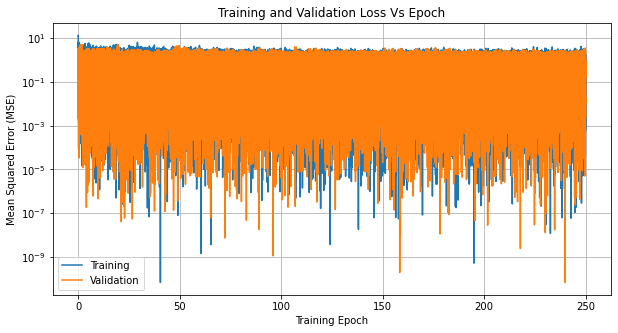

In [72]:
fig = plt.figure(figsize=(10, 5))
plt.plot(np.linspace(0, n_epochs, len(train_lossLog)), train_lossLog)
plt.plot(np.linspace(0, n_epochs, len(val_lossLog)), val_lossLog)
plt.xlabel("Training Epoch")
plt.ylabel("Mean Squared Error (MSE)")
plt.yscale("log")
title = plt.title("Training and Validation Loss Vs Epoch")
legend = plt.legend(["Training", "Validation"])
plt.grid()

In [73]:
test_outputs = predict_model(mlp1, test1x_dataloader)
max(test_outputs[:,0] - dx_out1[0,:,0])

1.1717022936288828

C:\Users\exy053\AppData\Local\Temp/ipykernel_436592/3089528512.py:8: UserWarning: The following kwargs were not used by contour: 'edgecolor'
  ctr = ax.tricontourf(x_, y_, val_, cmap="viridis", edgecolor=None)


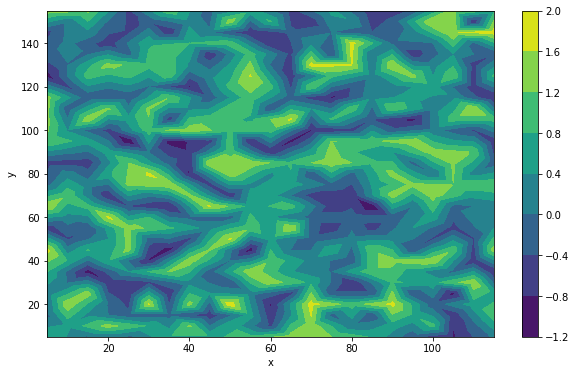

In [74]:
x_, y_ = train_in1[:,0], train_in1[:,1]
val_ = dx_out1[0,:,0] - test_outputs[:,0]

fig1 = plt.figure(figsize=(10, 6))
ax = fig1.add_subplot()
ax.set_xlabel('x')
ax.set_ylabel('y')
ctr = ax.tricontourf(x_, y_, val_, cmap="viridis", edgecolor=None)
plt.colorbar(ctr)

# Stress-Strain Curve Optimization
General approximation from change in node coordinate components to change in stress-strain curve.

### with MLP

In [157]:
in_size = train_in.shape[-1]
out_size = train_out.shape[-1]
h_size = [2**8, 2**8, 2**8]

BATCH_SIZE = 200
LEARNING_RATE = 1e-3
n_epochs = 250

In [158]:
trainDS = Dataset(train_in[:500], train_out[:500])
valDS = Dataset(val_in, val_out)
testDS = Dataset(test_in, test_out)

train_dataloader = DataLoader(dataset=trainDS, batch_size=BATCH_SIZE, shuffle=True)
val_dataloader = DataLoader(dataset=valDS, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(dataset=testDS, batch_size=BATCH_SIZE, shuffle=False)

In [159]:
DRN1 = DeepRitzResNN(in_size, h_size, out_size).to(device)
DRN1.apply(weights_init)
# print(torch.cuda.is_available())   ### TODO: GPU

opt = optim.Adam(DRN1.parameters(), lr=LEARNING_RATE)
lossf = nn.MSELoss()

def custom_loss(target, output):   ### TODO: Quantile loss
    return torch.mean((output - target)**2)

def physics_loss(target, output):
    return torch.abs(torch.sum(target) - torch.sum(output))

In [160]:
DRN1, train_lossLog, val_lossLog = train_model(DRN1, lossf, opt, n_epochs, train_dataloader, train_dataloader)

Epoch: 0 - Loss: 1.5219734907150269
Epoch: 10 - Loss: 0.6113753914833069
Epoch: 20 - Loss: 0.4202655255794525
Epoch: 30 - Loss: 0.3161962330341339
Epoch: 40 - Loss: 0.2125983089208603
Epoch: 50 - Loss: 0.14503292739391327
Epoch: 60 - Loss: 0.12615403532981873
Epoch: 70 - Loss: 0.09960190206766129
Epoch: 80 - Loss: 0.07640793919563293
Epoch: 90 - Loss: 0.0595194511115551
Epoch: 100 - Loss: 0.04651535302400589
Epoch: 110 - Loss: 0.04528260976076126
Epoch: 120 - Loss: 0.035678375512361526
Epoch: 130 - Loss: 0.030131028965115547
Epoch: 140 - Loss: 0.025485318154096603
Epoch: 150 - Loss: 0.023405062034726143
Epoch: 160 - Loss: 0.018060961738228798
Epoch: 170 - Loss: 0.017743270844221115
Epoch: 180 - Loss: 0.014435392804443836
Epoch: 190 - Loss: 0.012101463973522186
Epoch: 200 - Loss: 0.010727012529969215
Epoch: 210 - Loss: 0.009251849725842476
Epoch: 220 - Loss: 0.010146090760827065
Epoch: 230 - Loss: 0.008008922450244427
Epoch: 240 - Loss: 0.006967504043132067
Epoch: 250 - Loss: 0.00707977

In [161]:
test_outputs = predict_model(DRN1, train_dataloader)
#test_outputs = standardize(test_outputs, outParams[0], outParams[1], mode=1)

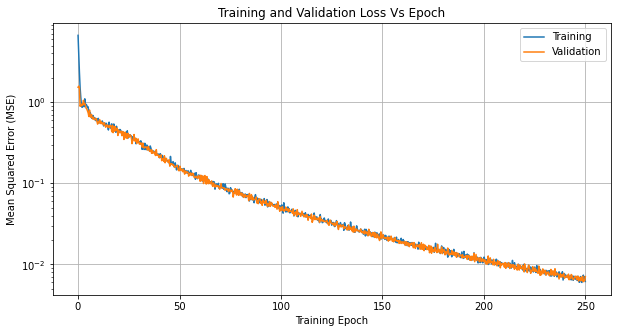

In [162]:
fig = plt.figure(figsize=(10, 5))
plt.plot(np.linspace(0, n_epochs, len(train_lossLog)), train_lossLog)
plt.plot(np.linspace(0, n_epochs, len(val_lossLog)), val_lossLog)
plt.xlabel("Training Epoch")
plt.ylabel("Mean Squared Error (MSE)")
plt.yscale("log")
title = plt.title("Training and Validation Loss Vs Epoch")
legend = plt.legend(["Training", "Validation"])
plt.grid()

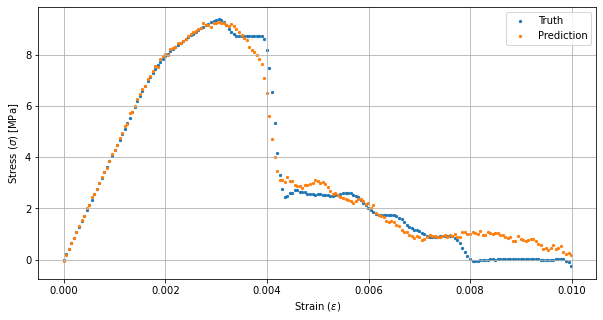

In [184]:
fig = plt.figure(figsize=(10, 5))
plt.scatter(perOUT[0], train_out[150]+perOUT[1], s=5, label="Truth")
plt.scatter(perOUT[0], test_outputs[150]+perOUT[1], s=5, label="Prediction")
plt.ylabel("Stress ($\sigma$) [MPa]")
plt.xlabel("Strain ($\epsilon$)")
plt.legend()
plt.grid()

In [182]:
err = list(abs(sum(train_out[:500] - test_outputs)))
err.index(min(err))

151